# Compare Four Datasets

Datasets of these `.tsp` files are from:

https://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp.html

In the task here, four datasets files that contains 70-150 cities will be compared.

The datasets file consist of `ch150.tsp`, `eil101.tsp`, `kroA100.tsp`, and `lin105.tsp`.

To make Python can read `.tsp` file format, we need to run pip below:

In [126]:
!pip install tsplib95 -q

In [127]:
import tsplib95
import matplotlib.pyplot as plt
import math

Below path is to retrieved file format for `.tsp`:

In [128]:
DRIVE_PATH = '/content/drive/MyDrive/Colab Notebooks/TC6544_Datasets Comparison/datasets-without-known-opt-tour/'

datasets = ['ch150', 'eil101', 'kroA100', 'lin105']

# To load and store coordinates from the files
def load_tsp(name):
  path    = DRIVE_PATH + f'{name}.tsp'
  problem = tsplib95.load(path)
  coords  = dict(problem.node_coords)
  return coords

## City Count

In this section, based on the bar chart below, we can see that these datasets contains cities that fulfil the required range of 70 - 150 cities, which confirms that the selected datasets are suitable for this task.

In [129]:
loaded = {}
for name in datasets:
  loaded[name] = load_tsp(name)
  print(f'{name}: {len(loaded[name])} cities count')

ch150: 150 cities count
eil101: 101 cities count
kroA100: 100 cities count
lin105: 105 cities count


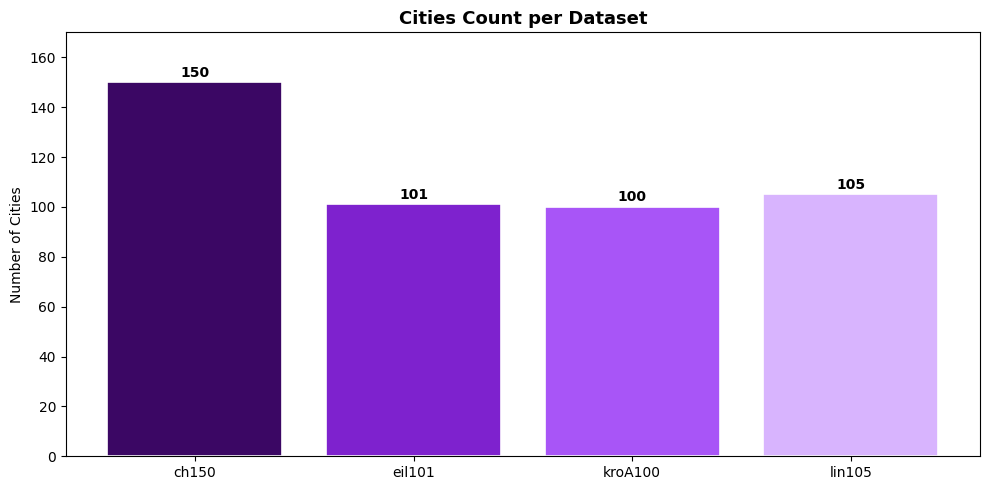

In [130]:
city_counts = {name: len(loaded[name]) for name in datasets}

# purple shades slay
colors = {
    'ch150'   : '#3B0764',   # deep violet
    'eil101'  : '#7E22CE',   # purple
    'kroA100' : '#A855F7',   # medium purple
    'lin105'  : '#D8B4FE'    # lavender
}

fig, ax = plt.subplots(figsize=(10, 5))
names = list(city_counts.keys())
counts = list(city_counts.values())
bars = ax.bar(names, counts,
              color=[colors[n] for n in names],
              edgecolor='white', linewidth=1.2)

ax.set_title('Cities Count per Dataset', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Cities', fontsize=10)
ax.set_ylim(0, max(counts) + 20)

#ax.axhline(y=70,  color='red',  linestyle='--', linewidth=1, alpha=0.6, label='Min required (70)')
#ax.axhline(y=150, color='blue', linestyle='--', linewidth=1, alpha=0.6, label='Max required (150)')
#ax.legend(fontsize=9)

for bar, val in zip(bars, counts):
  ax.text(bar.get_x() + bar.get_width()/2,
          bar.get_height() + 1,
          str(val), ha='center', va='bottom',
          fontweight='bold', fontsize=10)

plt.tight_layout()

# To save the picture, but no need
#plt.savefig(DRIVE_PATH + 'citycount.png',
#            dpi=150, bbox_inches='tight')

plt.show()

From the bar chart above, the **ch150** dataset has 150 cities, the **eil101** dataset has 101 cities, the **kroA100** dataset has 100 cities, and the **lin105** dataset has 105 cities.

Actually, from the dataset file name itself, we can know how many cities there.

## Coordinate Format

The coordinate format section determines on how distances between cities are calculated. All of these four datasets use **EUC_2D** format. This format means that the distances are computed using the standard two-dimensional Euclidean formula that was shown in Known Optimal Tour Length section.

In [131]:
def get_coord_format(name):
  # use the .tsp file path
  path = DRIVE_PATH + f'{name}.tsp'
  with open(path, 'r') as f:
    for line in f:
      # search for a line contains EDGE_WEIGHT_TYPE
      if 'EDGE_WEIGHT_TYPE' in line:
        # take the part after string was cut at :
        # because in the file it look like this: EDGE_WEIGHT_TYPE: EUC_2D
        # [0] is EDGE_WEIGHT_TYPE, [1] is EUC_2D
        # .strip() function as to delete space at the front and the back (if there any)
        return line.split(':')[1].strip()
  return 'Unknown'

# retrieve the format of all dataset
coord_formats = {name: get_coord_format(name) for name in datasets}

for name, fmt in coord_formats.items():
    print(f"  {name:10s} : {fmt}")


  ch150      : EUC_2D
  eil101     : EUC_2D
  kroA100    : EUC_2D
  lin105     : EUC_2D


Based on the block of codes above, all of the four datasets utilise the same **EUC_2D** distance format.

But these coordinate format doesn't serve as a differentiating factor in the dataset selection since all four datasets are equally compatible with GA implementation. It is because the EUC_2D format is straightforwad to compute and widely supported in TSP task.

## Known Optimal Tour Length

Datasets for `.opt.tour` files also from:

https://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp.html

The `.opt.tour` file contains the **sequence of cities**
that form the optimal tour (shortest path) that has
been proven by TSPLIB95.

Below path is to retrieved file format for  `opt.tour`:

In [132]:
DRIVE_PATH_1 = '/content/drive/MyDrive/Colab Notebooks/TC6544_Datasets Comparison/datasets-with-known-opt-tour/'

datasets_2 = ['ch150', 'eil101', 'kroA100', 'lin105']

In [133]:
# read_opt_tour(): reads file line by line
# and extracts the city sequence
def read_opt_tour(name):
  path  = DRIVE_PATH_1 + f'{name}.opt.tour'
  tour  = []
  with open(path, 'r') as f:
    reading = False
    for line in f:
      line = line.strip()
      if line == 'TOUR_SECTION':
        reading = True
        continue
      if line == '-1' or line == 'EOF':
        break
      if reading:
        # handle nombor dalam satu baris atau berbaris
        for token in line.split():
          if token.lstrip('-').isdigit():
            city = int(token)
            if city != -1:
              tour.append(city)
  return tour


The optimal tour length is calculate by adding the Euclidean 2D distances between cities and should be in the optimal tour sequences.

Euclidean 2D Formula:
$$d(i, j) = \sqrt{(x_i - x_j)^2 + (y_i - y_j)^2}$$

where:

- $d(i, j)$ = distance between city  $i$ and city $j$
- $x_i, y_i$ = city $i$ coordinate
- $x_j, y_j$ = city $j$ coordinate

Calculating Tour Length's Total Formula:

$$\text{Tour Length} = \sum_{i=1}^{n} d(\text{tour}[i],\ \text{tour}[(i+1)\ \%\ n])$$

Where:
- $\sum_{i=1}^{n}$ = sum all distances from city 1 to city $n$
- $d(\cdot, \cdot)$ = EUC\_2D distance between two cities
- $\text{tour}[i]$ = current city being visited
- $\text{tour}[(i+1)\ \%\ n]$ = next city to visit
- $\%\ n$ = modulo operator — ensures the last city
  returns back to the first city, completing the closed tour
- $n$ = total number of cities in the tour


In [134]:
# Function kira jarak
def euclidean(c1, c2):
  # original formula giving result as a floating point, not rounded,
  # so the optimal tour length might differ than what was stated inside file
  #return math.sqrt((c1[0]-c2[0])**2 + (c1[1]-c2[1])**2)

  # by adding 0.5, it will be rounded properly
  return int(math.sqrt((c1[0]-c2[0])**2 + (c1[1]-c2[1])**2) + 0.5)

def calc_tour_length(tour, coords):
  total = 0
  n = len(tour)
  for i in range(n):
    c1 = coords[tour[i]]
    c2 = coords[tour[(i+1) % n]]
    total += euclidean(c1, c2)
  return round(total)

opt_tours = {}
opt_lengths = {}

print("Known Optimal Tour Length:\n")

for name in datasets_2:
  opt_tours[name] = read_opt_tour(name)
  opt_lengths[name] = calc_tour_length(opt_tours[name], loaded[name])
  print(f'{name} = {opt_lengths[name]:,}')

Known Optimal Tour Length:

ch150 = 6,528
eil101 = 629
kroA100 = 21,282
lin105 = 14,379


Based on the counting we received shown above, **eil101** has the smallest optimal tour length (629), which tell us that the cities are very close to each other (highly packed). This can cause the Genetic Algorithm (GA) reach the solution much faster and reducing the difficulty and of the search space, providing little insight into its true performance.

Next, **lin105** has an optimal tour length of 14,379 and **ch150** has an optimal tour length of 6,528. Do note that the **ch150** has a smaller optimal value despite having more cities, which means it cities are more closely packed. And that will make the GA can locate the good solutions much easier since highly packed cities reduces the search space complexity.

Lastly, **kroA100** recorded a moderate optimal tour length of 21,282, which is telling us that its cities are well-distributed
across the search space. This balanced distribution makes it neither too easy nor too difficult for the GA, providing a fair environment to observe the algorithm's true search behaviour.


## Source Citation

All of these four datasets were obtained from **TSPLIBS95**, where it was introduced by Reinelt (1991) as a standardized benchmark library for the Travelling Salesman Problem (TSP).

In [138]:
citations = {
    'ch150'  : 'Churritz',
    'eil101' : 'Christofides & Eilon',
    'kroA100': 'Krolak, Felts & Nelson',
    'lin105' : 'Lin'
}

print("=" * 60)
print(f"  {'Dataset(s)':15s} {'Author':27s} {'Cities'}")
print("-" * 60)
for name in datasets_2:
    print(f"  {name:15s} {citations[name]:27s} {len(loaded[name])}")
print("=" * 60)
print("Source : TSPLIB95")
print("Reinelt, G. (1991). TSPLIB — A Traveling Salesman")
print("Problem Library. ORSA Journal on Computing")
#print("3(4), 376-384.")

  Dataset(s)      Author                      Cities
------------------------------------------------------------
  ch150           Churritz                    150
  eil101          Christofides & Eilon        101
  kroA100         Krolak, Felts & Nelson      100
  lin105          Lin                         105
Source : TSPLIB95
Reinelt, G. (1991). TSPLIB — A Traveling Salesman
Problem Library. ORSA Journal on Computing


# Conclusion

Therefore, based on the optimal tour length comparison, **kroA100** is selected to be the benchmark dataset for this task. It is because even though it contains 100 cities, it has an optimal tour length of 21,282, which shown that it is a well-distributed city layout that presents a balanced level of difficulty for the Genetic Algorithm.

Plus, kroA100 are within the required city range of 70 to 150 cities, making it a suitable problem size to demonstrate the full behaviour of the Genetic Algorithm.

All four candidate datasets share the same EUC_2D coordinate format, confirming that kroA100 is equally compatible with the GA implementation. Since this aspect is consistent across all candidates, the final selection determined by the
superiority of kroA100 in this three aspects, including this.

In conclusion, **kroA100** is the most suitable
benchmark dataset for this study, providing a
balanced problem size and a well-documented optimal
solution.